Retrying factor analysis and also probably messing with dataset still but needed new notebook for organiztional sake

In [47]:
import pandas as pd
from src.features import feature_encoder, transformers
from src.utils import data_utils
from src import plots
from sklearn.model_selection import train_test_split
import factor_analyzer
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv("../data/processed/3.0-jp-eda-df.csv", header=[0, 1, 2])

df_encoded = feature_encoder.encode_features(df.copy(), impute=True)

In [49]:
df_encoded = df_encoded.copy()

X = df_encoded.drop(columns=['ahi'])
y = data_utils.convert_ahi(df_encoded['ahi'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


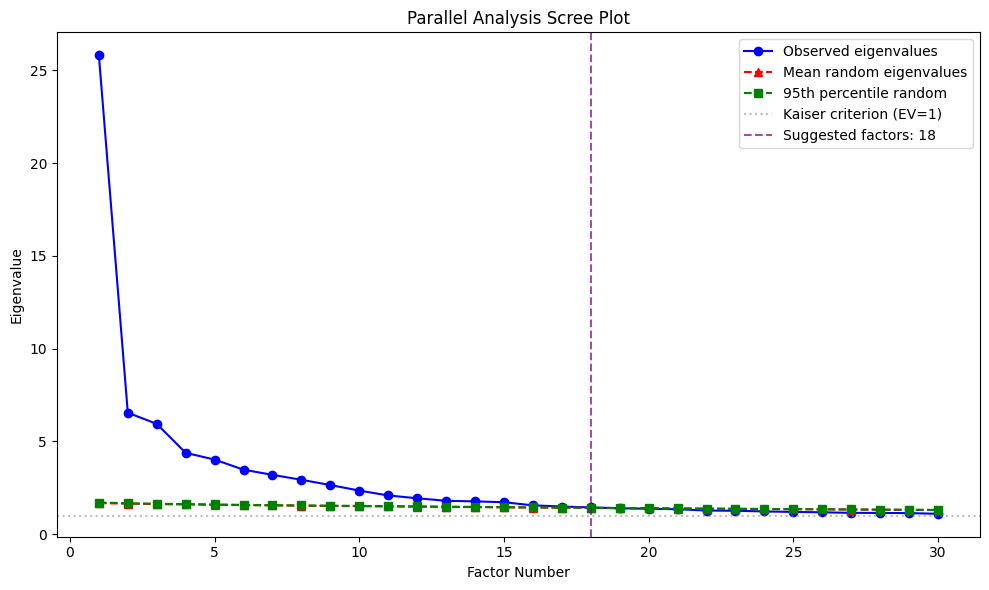


Parallel analysis suggests 18 factors


In [50]:
plots.parallel_analysis(X)

In [51]:
fa = factor_analyzer.FactorAnalyzer(rotation="varimax", n_factors=18)
fa.fit(X)

FactorAnalyzer(n_factors=18, rotation='varimax', rotation_kwargs={})

In [52]:
loadings = fa.loadings_
index = X.columns
columns = [f"factor_{i+1}" for i in range(fa.n_factors)]

loadings_df = pd.DataFrame(loadings, index=index, columns=columns)

for i in range(loadings.shape[1]):
            print(f"Top loadings for factor_{i+1}:")
            print(
                loadings_df[f"factor_{i+1}"].abs().sort_values(ascending=False).head(8)
            )
            print("\n")


Top loadings for factor_1:
fati_interferes_with_phys_function_fss       0.825343
fati_prevents_sustained_phys_func_fss        0.816061
fati_causes_freq_probs_for_me_fss            0.808601
fati_top_three_disabling_sympts_fss          0.807584
fati_interferes_with_responsibilities_fss    0.804462
fati_interferes_with_work_fam_social_fss     0.785312
i_am_easily_fati_fss                         0.768483
feel_no_energy_freq_phq                      0.561500
Name: factor_1, dtype: float64


Top loadings for factor_2:
isi_total_score                                0.862876
diff_staying_asleep_isi                        0.782748
how_satisfied_with_curr_sleep_pattern_isi      0.695190
troub_slp_nose                                 0.686497
slp_quality_sw                                 0.624824
diff_falling_asleep_isi                        0.564389
trouble_sleeping_or_too_much_sleep_freq_phq    0.563070
diff_falling_asleep_isq                        0.561965
Name: factor_2, dtype: float64




In [53]:
import semopy
import re

# Sanitize column names for semopy model syntax (no spaces, parens, etc.)
def sanitize_name(name):
    return re.sub(r"[^a-zA-Z0-9_]", "_", str(name))

name_map = {col: sanitize_name(col) for col in X.columns}
X_cfa = X.rename(columns=name_map)
X_test_cfa = X_test.rename(columns=name_map)
loadings_df_cfa = loadings_df.copy()
loadings_df_cfa.index = [name_map[c] for c in loadings_df.index]

# Assign each variable to the factor with the highest absolute loading
LOADING_THRESHOLD = 0.707  # minimum loading to include a variable

factor_assignments = {}
for var in loadings_df_cfa.index:
    row = loadings_df_cfa.loc[var]
    max_loading = row.abs().max()
    if max_loading >= LOADING_THRESHOLD:
        dominant_factor = row.abs().idxmax()
        factor_assignments.setdefault(dominant_factor, []).append(var)

# Build model spec — factors with <2 indicators are dropped (CFA requirement)
model_lines = [
    f"{factor} =~ {' + '.join(indicators)}"
    for factor, indicators in factor_assignments.items()
    if len(indicators) >= 2
]
model_spec = "\n".join(model_lines)
print(f"CFA model: {len(model_lines)} factors, "
      f"{sum(len(v) for v in factor_assignments.values() if len(v) >= 2)} indicators\n")
print(model_spec)

CFA model: 9 factors, 27 indicators

factor_10 =~ nasal_congestion_stuffiness_nose + nasal_blockage_obstr_nose + troub_brth_nose
factor_9 =~ feel_sleep_not_sound_isq + difficulty_staying_asleep_isq + multiple_awakenings_isq
factor_11 =~ map_index_4_narcolepsy_like_symptoms_score + hh_frequency_score
factor_6 =~ snorting_gasping_map + breathing_stops_map + map_index_1_apnea_score
factor_3 =~ ess_total_score + ess_chance_of_dozing_inactive_public
factor_2 =~ diff_staying_asleep_isi + isi_total_score
factor_4 =~ feeling_anxious_freq_gad + not_able_to_control_worrying_freq_gad + worry_too_much_diff_things_freq_gad
factor_1 =~ i_am_easily_fati_fss + fati_interferes_with_phys_function_fss + fati_causes_freq_probs_for_me_fss + fati_prevents_sustained_phys_func_fss + fati_interferes_with_responsibilities_fss + fati_top_three_disabling_sympts_fss + fati_interferes_with_work_fam_social_fss
factor_16 =~ dream_recall_frequency_infrequent + dream_recall_frequency_rarely_or_never


In [54]:
# Fit CFA on the holdout set (X_test) to validate the EFA-derived structure
cfa_model = semopy.Model(model_spec)
cfa_model.fit(X_test_cfa)

# Fit indices
fit_stats = semopy.calc_stats(cfa_model)
print(fit_stats.T)

                     Value
DoF             288.000000
DoF Baseline    351.000000
chi2            718.706660
chi2 p-value      0.000000
chi2 Baseline  7162.187536
CFI               0.936765
GFI               0.899653
AGFI              0.877702
NFI               0.899653
TLI               0.922932
RMSEA             0.067939
AIC             175.577190
BIC             516.121456
LogLik            2.211405


In [55]:
# Inspect parameter estimates (loadings, variances, covariances)
display(cfa_model.inspect())

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,nasal_congestion_stuffiness_nose,~,factor_10,1.000000,-,-,-
1,nasal_blockage_obstr_nose,~,factor_10,1.035962,0.065516,15.812272,0.0
2,troub_brth_nose,~,factor_10,1.088421,0.069137,15.743029,0.0
3,feel_sleep_not_sound_isq,~,factor_9,1.000000,-,-,-
4,difficulty_staying_asleep_isq,~,factor_9,1.556754,0.121551,12.807373,0.0
...,...,...,...,...,...,...,...
94,nasal_congestion_stuffiness_nose,~~,nasal_congestion_stuffiness_nose,0.442424,0.044702,9.897298,0.0
95,not_able_to_control_worrying_freq_gad,~~,not_able_to_control_worrying_freq_gad,0.098276,0.01605,6.123162,0.0
96,snorting_gasping_map,~~,snorting_gasping_map,0.775760,0.08266,9.384933,0.0
97,troub_brth_nose,~~,troub_brth_nose,0.290169,0.040062,7.242941,0.0
